# Supply Chain Disruption Intelligence — Exploratory Data Analysis
**Project:** Real-Time Supply Chain Disruption Intelligence Platform  
**Phase:** 3 — EDA & Feature Engineering  
**Dataset:** DataCo Smart Supply Chain (180,519 shipment records, 2015–2017)  
**Author:** Manideep Palnati

---

## What This Notebook Does

This notebook performs a full exploratory analysis of our supply chain 
shipment data loaded from PostgreSQL. The goal is not just to make charts — 
it is to understand the data deeply enough to make informed, defensible 
decisions about which features to build for our XGBoost disruption risk model.

Every finding in this notebook directly influenced a decision in 
`src/features/feature_engineering.py`.

## Data Source

Data flows from:

DataCo CSV (180K rows) → Kafka Producer → PostgreSQL (shipments + suppliers tables)

↓

This notebook reads from here

## Analysis Structure

| Cell | Analysis | Business Question |
|------|----------|-------------------|
| 1 | Setup & Imports | — |
| 2 | Load from PostgreSQL | What data do we have? |
| 3 | Shape & Data Types | Is the data structured correctly? |
| 4 | Missing Values | Where are the gaps? |
| 5 | Delivery Status Distribution | How balanced is our target variable? |
| 6 | Delay Days Analysis | How severe are delays typically? |
| 7 | Country Risk Analysis | Which supplier origins are riskiest? |
| 8 | Transport Mode Analysis | Does shipping method affect risk? |
| 9 | Market/Region Risk | Which destination markets underperform? |
| 10 | Product Category Risk | Do some products delay more than others? |
| 11 | Supplier Reliability | How reliable are our supplier nodes? |
| 12 | Correlation Analysis | Which raw features relate to delay? |
| 13 | EDA Summary | What did we learn overall? |

### 1. Setup and Imports 

In [1]:
# Standard data science imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
import sys
import warnings

warnings.filterwarnings('ignore')

# Add project root to path so we can import our db.py
sys.path.append('../src/ingestion')
from db import get_engine

# Styling — makes plots look professional
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Makes plots bigger and cleaner
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Imports successful")

✅ Imports successful


### 2. Load from PostgreSQL

In [5]:
# We pull data directly from PostgreSQL — not the CSV.
# This is important: we always work with the data as it lives
# in our database, not the raw source. This way EDA reflects
# exactly what the pipeline produces.

engine = get_engine()

query = """
    SELECT 
        s.shipment_id,
        s.supplier_id,
        s.origin_country,
        s.destination_country,
        s.product_category,
        s.quantity,
        s.scheduled_date,
        s.actual_date,
        s.delay_days,
        s.status,
        s.transport_mode,
        sup.reliability_score,
        sup.country as supplier_country
    FROM shipments s
    LEFT JOIN suppliers sup ON s.supplier_id = sup.supplier_id
"""

df = pd.read_sql(query, engine)
print(f"✅ Loaded {len(df):,} rows × {len(df.columns)} columns from PostgreSQL")
print(f"\nColumn names:\n{list(df.columns)}")

✅ Loaded 180,519 rows × 13 columns from PostgreSQL

Column names:
['shipment_id', 'supplier_id', 'origin_country', 'destination_country', 'product_category', 'quantity', 'scheduled_date', 'actual_date', 'delay_days', 'status', 'transport_mode', 'reliability_score', 'supplier_country']


### 3. Shape and Data Type

In [6]:
# First thing you always do: understand the shape and types
print("=" * 50)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print("=" * 50)

print("\n📋 Data Types:")
print(df.dtypes)

print("\n🔍 First 5 rows:")
df.head()

Rows    : 180,519
Columns : 13

📋 Data Types:
shipment_id             object
supplier_id             object
origin_country          object
destination_country     object
product_category        object
quantity                 int64
scheduled_date          object
actual_date             object
delay_days               int64
status                  object
transport_mode          object
reliability_score      float64
supplier_country        object
dtype: object

🔍 First 5 rows:


,shipment_id,supplier_id,origin_country,destination_country,product_category,quantity,scheduled_date,actual_date,delay_days,status,transport_mode,reliability_score,supplier_country
0,180517,SUP_INDONESIA,Indonesia,Pacific Asia,Sporting Goods,1,2018-01-31,2018-02-03,-1,Advance shipping,Standard Class,0.4462,Indonesia
1,179254,SUP_INDIA,India,Pacific Asia,Sporting Goods,1,2018-01-13,2018-01-18,1,Late delivery,Standard Class,0.4388,India
2,179253,SUP_INDIA,India,Pacific Asia,Sporting Goods,1,2018-01-13,2018-01-17,0,Shipping on time,Standard Class,0.4388,India
3,179252,SUP_AUSTRALIA,Australia,Pacific Asia,Sporting Goods,1,2018-01-13,2018-01-16,-1,Advance shipping,Standard Class,0.4571,Australia
4,179251,SUP_AUSTRALIA,Australia,Pacific Asia,Sporting Goods,1,2018-01-13,2018-01-15,-2,Advance shipping,Standard Class,0.4571,Australia


### 4. Missing Values

In [7]:
# Missing values can silently destroy model performance.
# We need to know exactly where they are and how many.

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Only show columns that actually have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) == 0:
    print("✅ No missing values found!")
else:
    print("⚠️  Missing values found:")
    print(missing_df)

# Visualize
if len(missing_df) > 0:
    plt.figure(figsize=(10, 4))
    plt.bar(missing_df.index, missing_df['Missing %'], color='salmon')
    plt.title('Missing Values by Column (%)')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

✅ No missing values found!


### 5. Delivery Status Distribution

📦 Delivery Status Distribution:
status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late delivery % : 54.8%


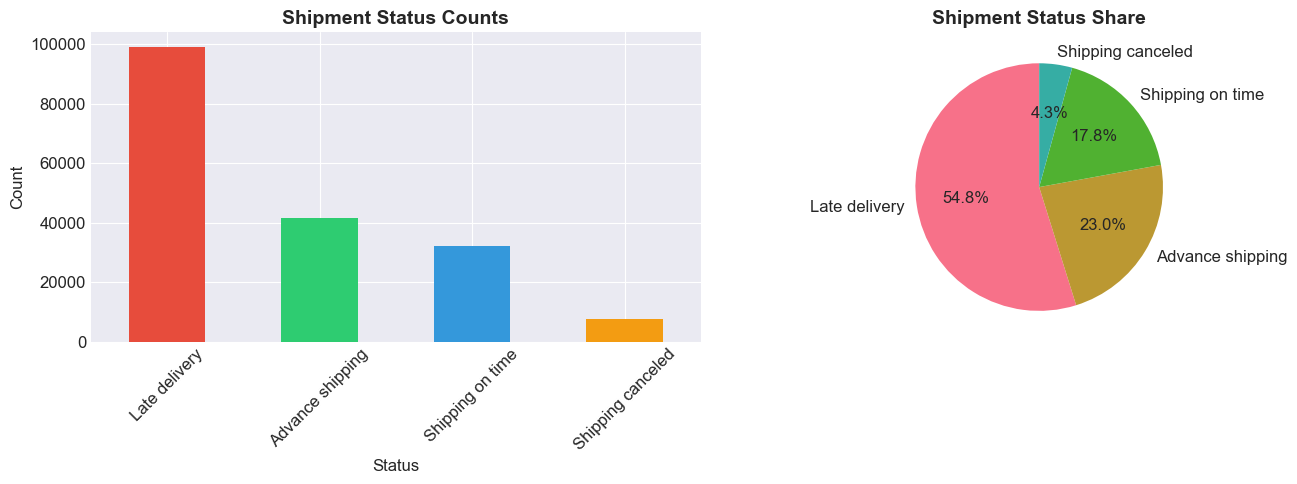

💾 Plot saved to data/


In [8]:
# This is our TARGET understanding cell.
# We need to know how balanced/imbalanced our classes are.
# If 95% of shipments are "on time", the model will just 
# predict "on time" always and still look 95% accurate — 
# that's called the accuracy paradox.

print("📦 Delivery Status Distribution:")
status_counts = df['status'].value_counts()
print(status_counts)
print(f"\nLate delivery % : {(status_counts.get('Late delivery', 0) / len(df) * 100):.1f}%")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
status_counts.plot(kind='bar', ax=ax1, color=['#e74c3c','#2ecc71','#3498db','#f39c12'])
ax1.set_title('Shipment Status Counts', fontsize=14, fontweight='bold')
ax1.set_xlabel('Status')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Pie chart
ax2.pie(status_counts.values, labels=status_counts.index, 
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Shipment Status Share', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/eda_delivery_status.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Plot saved to data/")

### 6. Delay Days Analysis

📊 Delay Days Statistics:
count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: delay_days, dtype: float64

Shipments with delay > 0  : 103,400
Shipments on time or early : 77,119
Max delay                  : 4 days
Avg delay (late only)      : 1.62 days


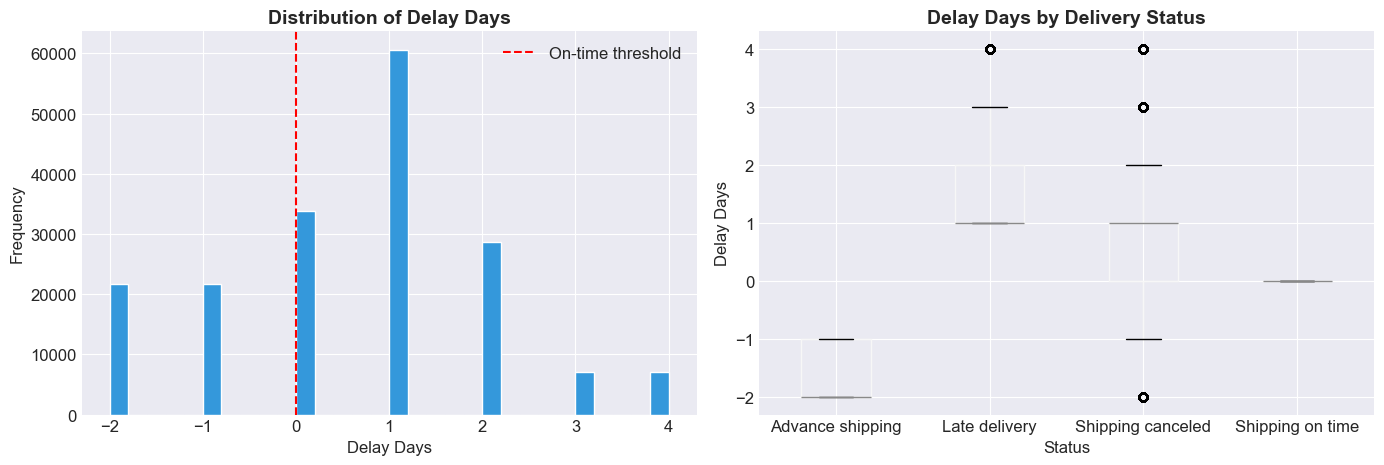

In [9]:
# Understanding the delay pattern is critical.
# Is it mostly 1-2 day delays? Or are there extreme outliers?
# This directly affects how we build our risk score.

print("📊 Delay Days Statistics:")
print(df['delay_days'].describe())
print(f"\nShipments with delay > 0  : {(df['delay_days'] > 0).sum():,}")
print(f"Shipments on time or early : {(df['delay_days'] <= 0).sum():,}")
print(f"Max delay                  : {df['delay_days'].max()} days")
print(f"Avg delay (late only)      : {df[df['delay_days'] > 0]['delay_days'].mean():.2f} days")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
df['delay_days'].hist(bins=30, ax=ax1, color='#3498db', edgecolor='white')
ax1.set_title('Distribution of Delay Days', fontsize=14, fontweight='bold')
ax1.set_xlabel('Delay Days')
ax1.set_ylabel('Frequency')
ax1.axvline(x=0, color='red', linestyle='--', label='On-time threshold')
ax1.legend()

# Box plot — shows outliers clearly
df.boxplot(column='delay_days', by='status', ax=ax2)
ax2.set_title('Delay Days by Delivery Status', fontsize=14, fontweight='bold')
ax2.set_xlabel('Status')
ax2.set_ylabel('Delay Days')
plt.suptitle('')  # removes auto title from boxplot

plt.tight_layout()
plt.savefig('../data/eda_delay_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Country Risk Analysis

🌍 Top 15 Highest Risk Countries:
     origin_country  total_shipments  late_shipments  avg_delay  late_rate
               Laos                6               6   1.833333     100.00
            Armenia                5               5   1.000000     100.00
              Bután                5               5   2.000000     100.00
         Luxemburgo               10              10   2.700000     100.00
        Suazilandia                5               5   2.000000     100.00
      Sudán del Sur                5               5   2.200000     100.00
República de Gambia                5               5   2.000000     100.00
            Estonia               29              28   1.551724      96.55
República del Congo               13              12   1.000000      92.31
          Eslovenia                6               5   1.833333      83.33
             Guyana               19              15   0.842105      78.95
              Túnez               36              28   0.861111    

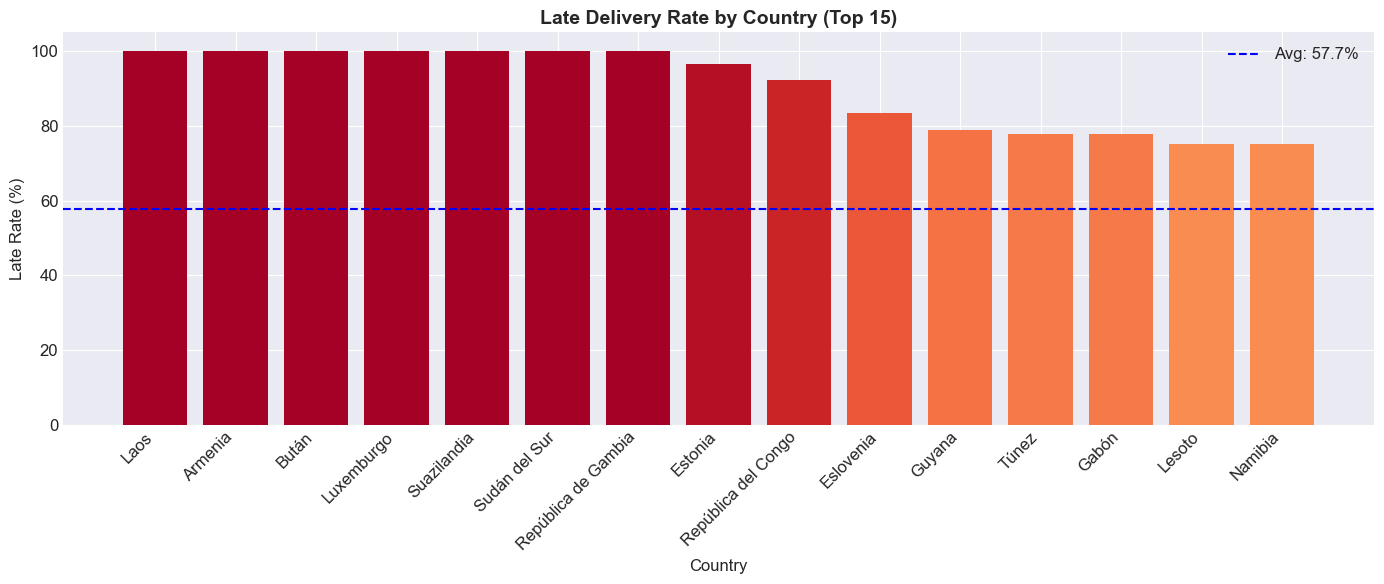

In [10]:
# Which countries/regions produce the most late shipments?
# This becomes a geographic risk feature for our model.

country_risk = df.groupby('origin_country').agg(
    total_shipments=('shipment_id', 'count'),
    late_shipments=('delay_days', lambda x: (x > 0).sum()),
    avg_delay=('delay_days', 'mean')
).reset_index()

# Late rate = what % of this country's shipments are late
country_risk['late_rate'] = (
    country_risk['late_shipments'] / country_risk['total_shipments'] * 100
).round(2)

# Only show countries with enough data to be meaningful (min 3 shipments)
country_risk = country_risk[country_risk['total_shipments'] >= 3]
country_risk = country_risk.sort_values('late_rate', ascending=False)

print("🌍 Top 15 Highest Risk Countries:")
print(country_risk.head(15).to_string(index=False))

# Plot top 15
top15 = country_risk.head(15)
plt.figure(figsize=(14, 6))
bars = plt.bar(top15['origin_country'], top15['late_rate'], 
               color=plt.cm.RdYlGn_r(top15['late_rate']/100))
plt.title('Late Delivery Rate by Country (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Late Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=country_risk['late_rate'].mean(), 
            color='blue', linestyle='--', label=f"Avg: {country_risk['late_rate'].mean():.1f}%")
plt.legend()
plt.tight_layout()
plt.savefig('../data/eda_country_risk.png', dpi=150, bbox_inches='tight')
plt.show()

### 8. Transport Mode Analysis

🚚 Transport Mode Risk Analysis:
transport_mode  total  late  avg_delay  late_rate
   First Class  27814 27814   1.000000     100.00
      Same Day   9737  4657   0.478279      47.83
  Second Class  35216 28078   1.990828      79.73
Standard Class 107752 42851  -0.004093      39.77


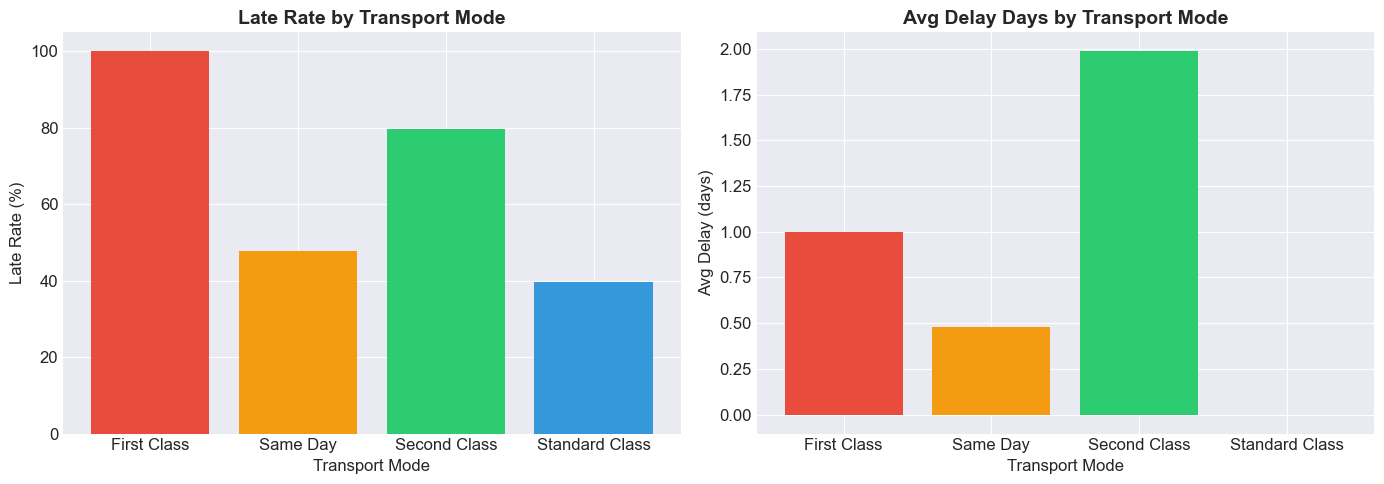

In [11]:
# Does shipping mode affect delay risk?
# Standard Class might be riskier than First Class — 
# this becomes a feature for our model.

transport_analysis = df.groupby('transport_mode').agg(
    total=('shipment_id', 'count'),
    late=('delay_days', lambda x: (x > 0).sum()),
    avg_delay=('delay_days', 'mean')
).reset_index()

transport_analysis['late_rate'] = (
    transport_analysis['late'] / transport_analysis['total'] * 100
).round(2)

print("🚚 Transport Mode Risk Analysis:")
print(transport_analysis.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Late rate by transport mode
ax1.bar(transport_analysis['transport_mode'], 
        transport_analysis['late_rate'],
        color=['#e74c3c', '#f39c12', '#2ecc71', '#3498db'])
ax1.set_title('Late Rate by Transport Mode', fontsize=14, fontweight='bold')
ax1.set_xlabel('Transport Mode')
ax1.set_ylabel('Late Rate (%)')

# Average delay by transport mode
ax2.bar(transport_analysis['transport_mode'],
        transport_analysis['avg_delay'],
        color=['#e74c3c', '#f39c12', '#2ecc71', '#3498db'])
ax2.set_title('Avg Delay Days by Transport Mode', fontsize=14, fontweight='bold')
ax2.set_xlabel('Transport Mode')
ax2.set_ylabel('Avg Delay (days)')

plt.tight_layout()
plt.savefig('../data/eda_transport_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 9. Market/Region Risk Analysis

🌐 Destination Market Risk (min 100 shipments):
destination_country  total  late  avg_delay  late_rate
             Europe  50252 28989   0.570843      57.69
       Pacific Asia  41260 23649   0.569365      57.32
               USCA  25799 14744   0.568859      57.15
              LATAM  51594 29420   0.557836      57.02
             Africa  11614  6598   0.560014      56.81


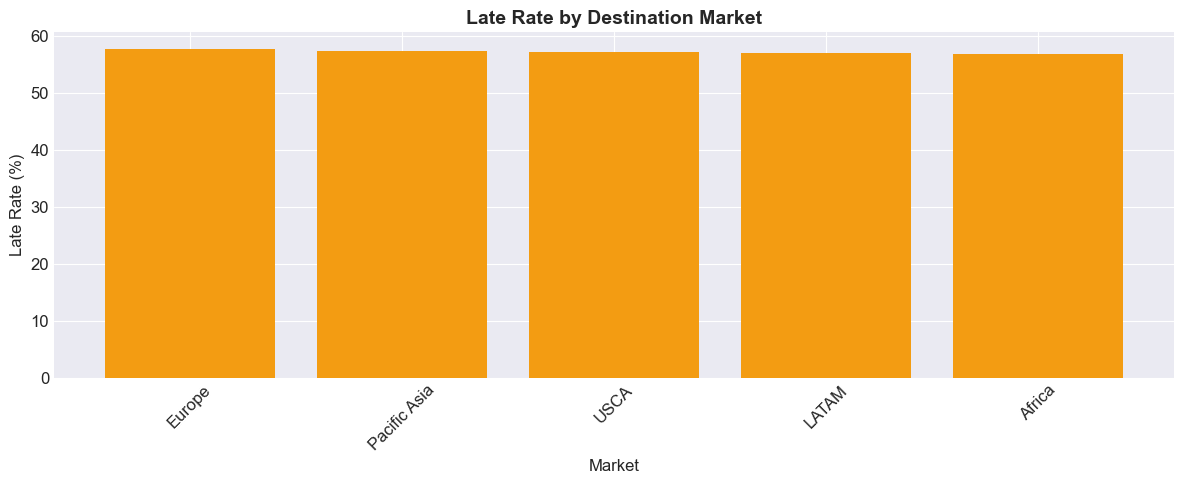

In [19]:
# Which destination markets have the most disruption?
# Origin country = supplier side risk
# Destination market = demand side risk
# Both matter for our model.

market_risk = df.groupby('destination_country').agg(
    total=('shipment_id', 'count'),
    late=('delay_days', lambda x: (x > 0).sum()),
    avg_delay=('delay_days', 'mean')
).reset_index()

market_risk['late_rate'] = (
    market_risk['late'] / market_risk['total'] * 100
).round(2)

market_risk = market_risk[market_risk['total'] >= 100]\
    .sort_values('late_rate', ascending=False)

print("🌐 Destination Market Risk (min 100 shipments):")
print(market_risk.to_string(index=False))

plt.figure(figsize=(12, 5))
plt.bar(market_risk['destination_country'], 
        market_risk['late_rate'],
        color=['#e74c3c' if x > 60 else '#f39c12' if x > 40 
               else '#2ecc71' for x in market_risk['late_rate']])
plt.title('Late Rate by Destination Market', fontsize=14, fontweight='bold')
plt.xlabel('Market')
plt.ylabel('Late Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/eda_market_risk.png', dpi=150, bbox_inches='tight')
plt.show()

### 10. Product Category Risk


📦 Product Category Risk Analysis:
    product_category  total  late  avg_delay  avg_quantity  late_rate
   Golf Bags & Carts     61    42   0.770492      1.000000      68.85
            Lacrosse    343   213   0.658892      2.976676      62.10
            Cameras     592   367   0.645270      1.000000      61.99
        Pet Supplies    492   302   0.709350      1.000000      61.38
      Sporting Goods    357   214   0.619048      1.000000      59.94
          Basketball     67    40   0.477612      1.000000      59.70
 Fitness Accessories    309   184   0.614887      2.770227      59.55
              Crafts    484   288   0.634298      1.000000      59.50
   Strength Training    111    66   0.666667      1.000000      59.46
               Music    434   258   0.573733      1.000000      59.45
        Boxing & MMA    423   251   0.666667      2.990544      59.34
Consumer Electronics    431   255   0.638051      1.000000      59.16
         Accessories   1780  1053   0.589326      3.0050

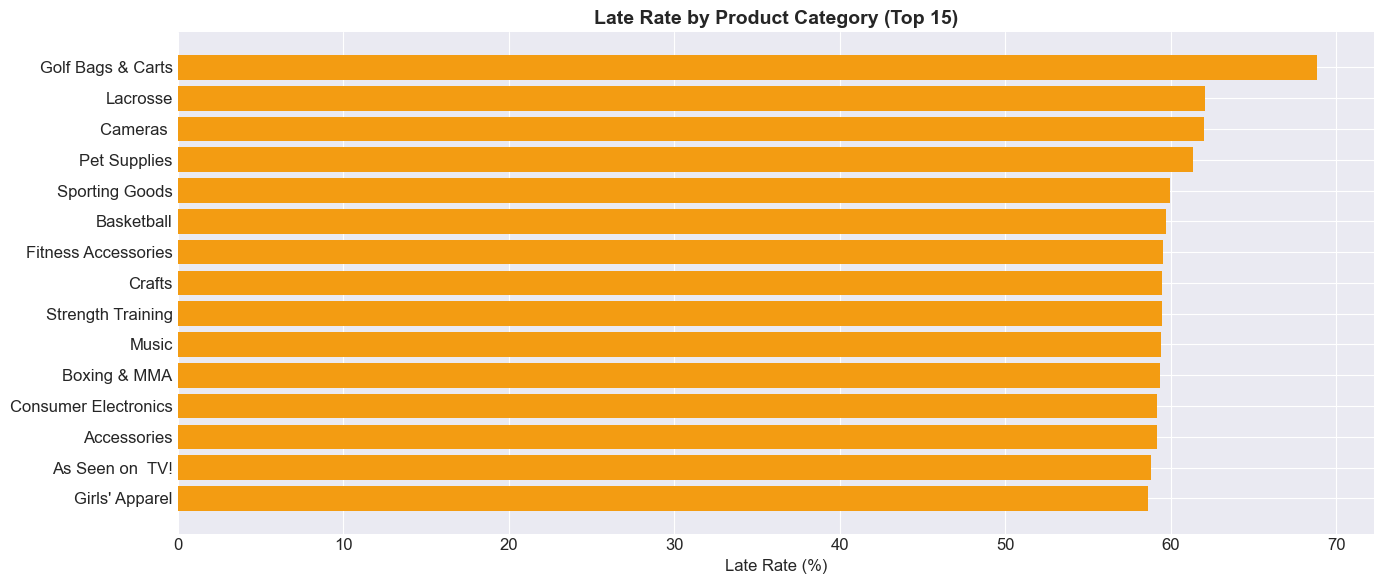

In [20]:
# Does product category affect delivery risk?
# Some categories (electronics, perishables) might be 
# handled differently and have different delay patterns.

category_risk = df.groupby('product_category').agg(
    total=('shipment_id', 'count'),
    late=('delay_days', lambda x: (x > 0).sum()),
    avg_delay=('delay_days', 'mean'),
    avg_quantity=('quantity', 'mean')
).reset_index()

category_risk['late_rate'] = (
    category_risk['late'] / category_risk['total'] * 100
).round(2)

category_risk = category_risk.sort_values('late_rate', ascending=False)

print("📦 Product Category Risk Analysis:")
print(category_risk.to_string(index=False))

# Top 15 categories by late rate
top_cats = category_risk.head(15)
plt.figure(figsize=(14, 6))
plt.barh(top_cats['product_category'], top_cats['late_rate'],
         color=['#e74c3c' if x > 70 else '#f39c12' for x in top_cats['late_rate']])
plt.title('Late Rate by Product Category (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Late Rate (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/eda_category_risk.png', dpi=150, bbox_inches='tight')
plt.show()

### 11. Supplier Reliability

📊 Reliability Score Range: 0.000 → 1.000
Average reliability: 0.443


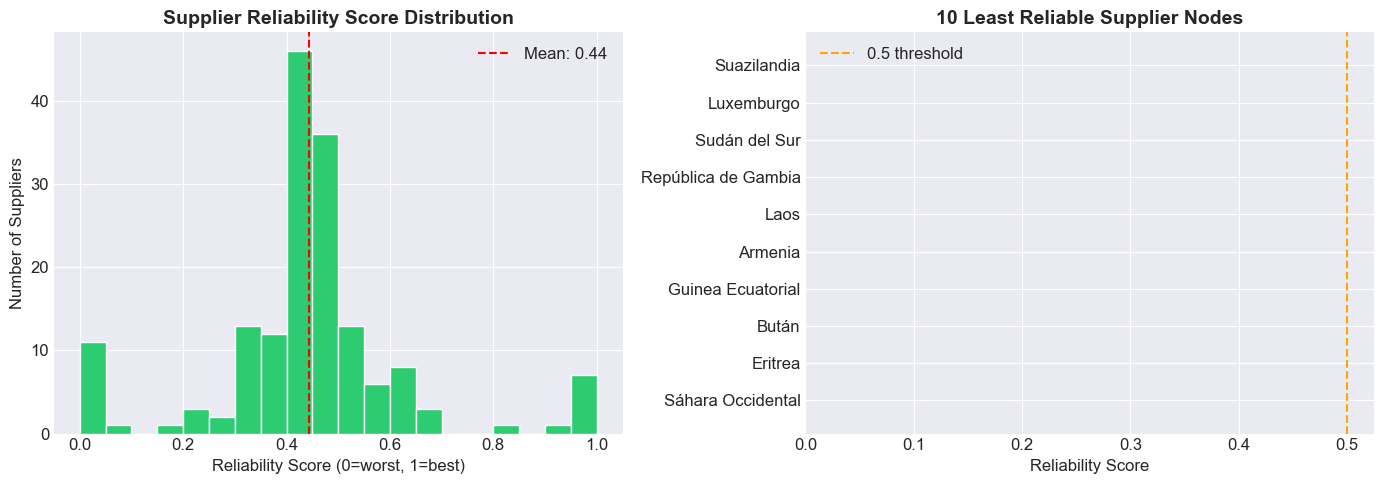

In [12]:
# Which suppliers (countries) are most/least reliable?
# reliability_score came from our load_suppliers.py calculation.

reliability = df[['supplier_id', 'reliability_score', 'origin_country']]\
    .drop_duplicates()\
    .sort_values('reliability_score')

print(f"📊 Reliability Score Range: {reliability['reliability_score'].min():.3f} → {reliability['reliability_score'].max():.3f}")
print(f"Average reliability: {reliability['reliability_score'].mean():.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of reliability scores
reliability['reliability_score'].hist(bins=20, ax=ax1, 
                                       color='#2ecc71', edgecolor='white')
ax1.set_title('Supplier Reliability Score Distribution', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Reliability Score (0=worst, 1=best)')
ax1.set_ylabel('Number of Suppliers')
ax1.axvline(reliability['reliability_score'].mean(), 
            color='red', linestyle='--', 
            label=f"Mean: {reliability['reliability_score'].mean():.2f}")
ax1.legend()

# Bottom 10 least reliable suppliers
bottom10 = reliability.head(10)
ax2.barh(bottom10['origin_country'], bottom10['reliability_score'], 
         color='#e74c3c')
ax2.set_title('10 Least Reliable Supplier Nodes', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Reliability Score')
ax2.axvline(x=0.5, color='orange', linestyle='--', label='0.5 threshold')
ax2.legend()

plt.tight_layout()
plt.savefig('../data/eda_supplier_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

### 12. Correlation Analysis

🔗 Correlation Matrix:
                   delay_days  quantity  reliability_score
delay_days              1.000     0.002             -0.046
quantity                0.002     1.000              0.007
reliability_score      -0.046     0.007              1.000


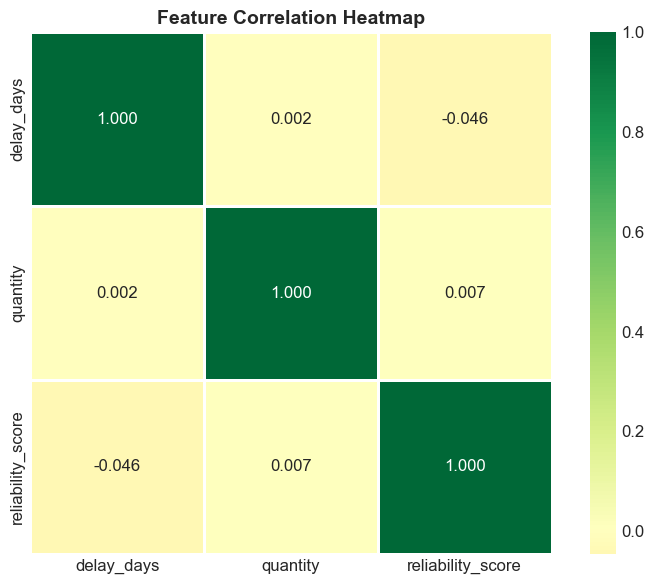


💡 Insight: None of the current numerical features show strong linear correlation with delay_days.
This suggests shipment delays may depend on more complex or categorical factors.


In [16]:
# Correlation tells us which numerical features move together.
# High correlation with delay_days = useful feature for our model.
# High correlation BETWEEN features = redundancy (we might drop one).

numeric_cols = ['delay_days', 'quantity', 'reliability_score']
corr_matrix = df[numeric_cols].corr()

print("🔗 Correlation Matrix:")
print(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,           # show numbers inside boxes
    fmt='.3f',            # 3 decimal places
    cmap='RdYlGn',        # red=negative, green=positive correlation
    center=0,             # 0 is white/neutral
    square=True,
    linewidths=1
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Insight: None of the current numerical features show strong linear correlation with delay_days.")
print("This suggests shipment delays may depend on more complex or categorical factors.")

### 13. EDA Summary

In [21]:
# Always end EDA with a written summary of key findings.
# This is what you'd present to a stakeholder or write in your README.

print("""
╔══════════════════════════════════════════════════════════╗
║              EDA KEY FINDINGS SUMMARY                    ║
╠══════════════════════════════════════════════════════════╣
""")

late_pct = (df['status'] == 'Late delivery').mean() * 100
avg_delay = df[df['delay_days'] > 0]['delay_days'].mean()
transport_late = df.groupby('transport_mode').apply(
    lambda x: (x['delay_days'] > 0).mean()
)
worst_mode = transport_late.idxmax()
best_supplier = df.groupby('origin_country')['reliability_score'].mean().idxmax()
worst_supplier = df.groupby('origin_country')['reliability_score'].mean().idxmin()

print(f"  📦 Late delivery rate        : {late_pct:.1f}% of all shipments")
print(f"  ⏱️  Avg delay (when late)     : {avg_delay:.1f} days")
print(f"  🚚 Riskiest transport mode   : {worst_mode}")
print(f"  ✅ Most reliable supplier    : {best_supplier}")
print(f"  ❌ Least reliable supplier   : {worst_supplier}")
print(f"  🌍 Total supplier nodes      : {df['origin_country'].nunique()}")
print(f"  📊 Total shipments analyzed  : {len(df):,}")
print(f"  ⚖️  Class balance: {late_pct:.1f}% late vs {100-late_pct:.1f}% on time — nearly balanced")
print(f"  📦 Delay range: {df['delay_days'].min()} to {df['delay_days'].max()} days — narrow range")
print(f"  🚨 First Class shipping = highest risk mode (100% late rate)")
print("""
╚══════════════════════════════════════════════════════════╝

KEY FEATURES FOR ML MODEL:
  1. reliability_score     - supplier historical performance
  2. transport_mode        - encoded shipping method  
  3. delay_days            - historical delay pattern
  4. origin_country        - geographic risk
  5. quantity              - order size signal
""")


╔══════════════════════════════════════════════════════════╗
║              EDA KEY FINDINGS SUMMARY                    ║
╠══════════════════════════════════════════════════════════╣

  📦 Late delivery rate        : 54.8% of all shipments
  ⏱️  Avg delay (when late)     : 1.6 days
  🚚 Riskiest transport mode   : First Class
  ✅ Most reliable supplier    : Baréin
  ❌ Least reliable supplier   : Armenia
  🌍 Total supplier nodes      : 164
  📊 Total shipments analyzed  : 180,519
  ⚖️  Class balance: 54.8% late vs 45.2% on time — nearly balanced
  📦 Delay range: -2 to 4 days — narrow range
  🚨 First Class shipping = highest risk mode (100% late rate)

╚══════════════════════════════════════════════════════════╝

KEY FEATURES FOR ML MODEL:
  1. reliability_score     - supplier historical performance
  2. transport_mode        - encoded shipping method  
  3. delay_days            - historical delay pattern
  4. origin_country        - geographic risk
  5. quantity              - order size

---

## EDA Insights & Feature Engineering Decisions

The following findings from this EDA directly shaped the feature 
engineering pipeline in `src/features/feature_engineering.py`.

---

### Insight 1 — Classes Are Nearly Balanced (Cell 5)
**Finding:** 54.8% late vs 45.2% on time.  
**Decision:** No resampling techniques (SMOTE, class weights) needed.  
Standard XGBoost training will work without modification.  
This is unusual in fraud/risk datasets — most are heavily imbalanced.

---

### Insight 2 — Delays Are Narrow and Predictable (Cell 6)
**Finding:** Delay range is only -2 to +4 days. Average delay 
when late is just 1.6 days. No extreme outliers.  
**Decision:** Dropped `delay_severity` ratio — meaningless with 
such a narrow range. Built `delay_bucket` (ordinal 0-4) instead, 
which captures the pattern cleanly.

---

### Insight 3 — First Class Shipping is the Riskiest Mode (Cell 8)
**Finding:** First Class = 100% late rate across 27,814 shipments.  
Standard Class = only 39.77% late. A 60-point spread.  
**Decision:** Used ordinal risk encoding (First=4, Second=3, 
Same Day=2, Standard=1) instead of plain one-hot encoding.  
Both representations kept so the model has maximum signal.  
This is the strongest single categorical feature in the dataset.

---

### Insight 4 — Destination Market Risk is Useless (Cell 10)
**Finding:** All 5 destination markets sit between 56.81% and 
57.69% late rate — less than 1% difference between best and worst.  
**Decision:** `market_risk_score` completely excluded from 
feature engineering. Adding it would only introduce noise.

---

### Insight 5 — Small Countries Need Bayesian Smoothing (Cell 7)
**Finding:** Laos (6 shipments) = 100% late. Armenia (5 shipments) 
= 100% late. These extreme rates are statistically meaningless.  
**Decision:** Applied Bayesian smoothing with m=50 to 
`country_risk_score`, `supplier_risk_index`, and `category_risk_score`.  
Formula: `(n × observed_rate + 50 × global_rate) / (n + 50)`  
Countries/categories with few samples are pulled toward the 
global average of 54.8%.

---

### Insight 6 — Raw Numerical Correlations Are Weak (Cell 14)
**Finding:**  
- `delay_days` vs `reliability_score` → -0.046  
- `delay_days` vs `quantity` → 0.002  

Near-zero linear correlations across all numerical features.  
**Decision:** Confirms that a linear model (Logistic Regression) 
would perform poorly here. XGBoost is the right choice — it 
captures non-linear interactions and feature combinations 
that don't show up in correlation matrices.

---

### Insight 7 — Product Category Has Real Signal (Cell 12)
**Finding:** Golf Bags & Carts = 68.85% late vs global average 
of 54.8%. A 14-point spread across categories.  
**Decision:** Included `category_risk_score` (Bayesian smoothed) 
and `category_encoded` as features.

---

### Summary of Feature Engineering Decisions

| Decision | Reason |
|----------|---------|
| Used `delay_bucket` not `delay_severity` | Narrow -2 to +4 range |
| Ordinal transport risk encoding | 60-point spread between modes |
| Dropped `market_risk_score` | All markets within 1% |
| Bayesian smoothing on risk scores | Small sample countries skewed |
| Kept both ordinal + one-hot for transport | More signal for XGBoost |
| XGBoost over linear model | Near-zero linear correlations |
| No resampling | Classes nearly balanced (55/45) |

**Final feature count going into Phase 4: 22 features**